In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read CSV file from data directory
df = pd.read_csv("../data/dataset.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


Head of the dataset:

Info about the dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSig

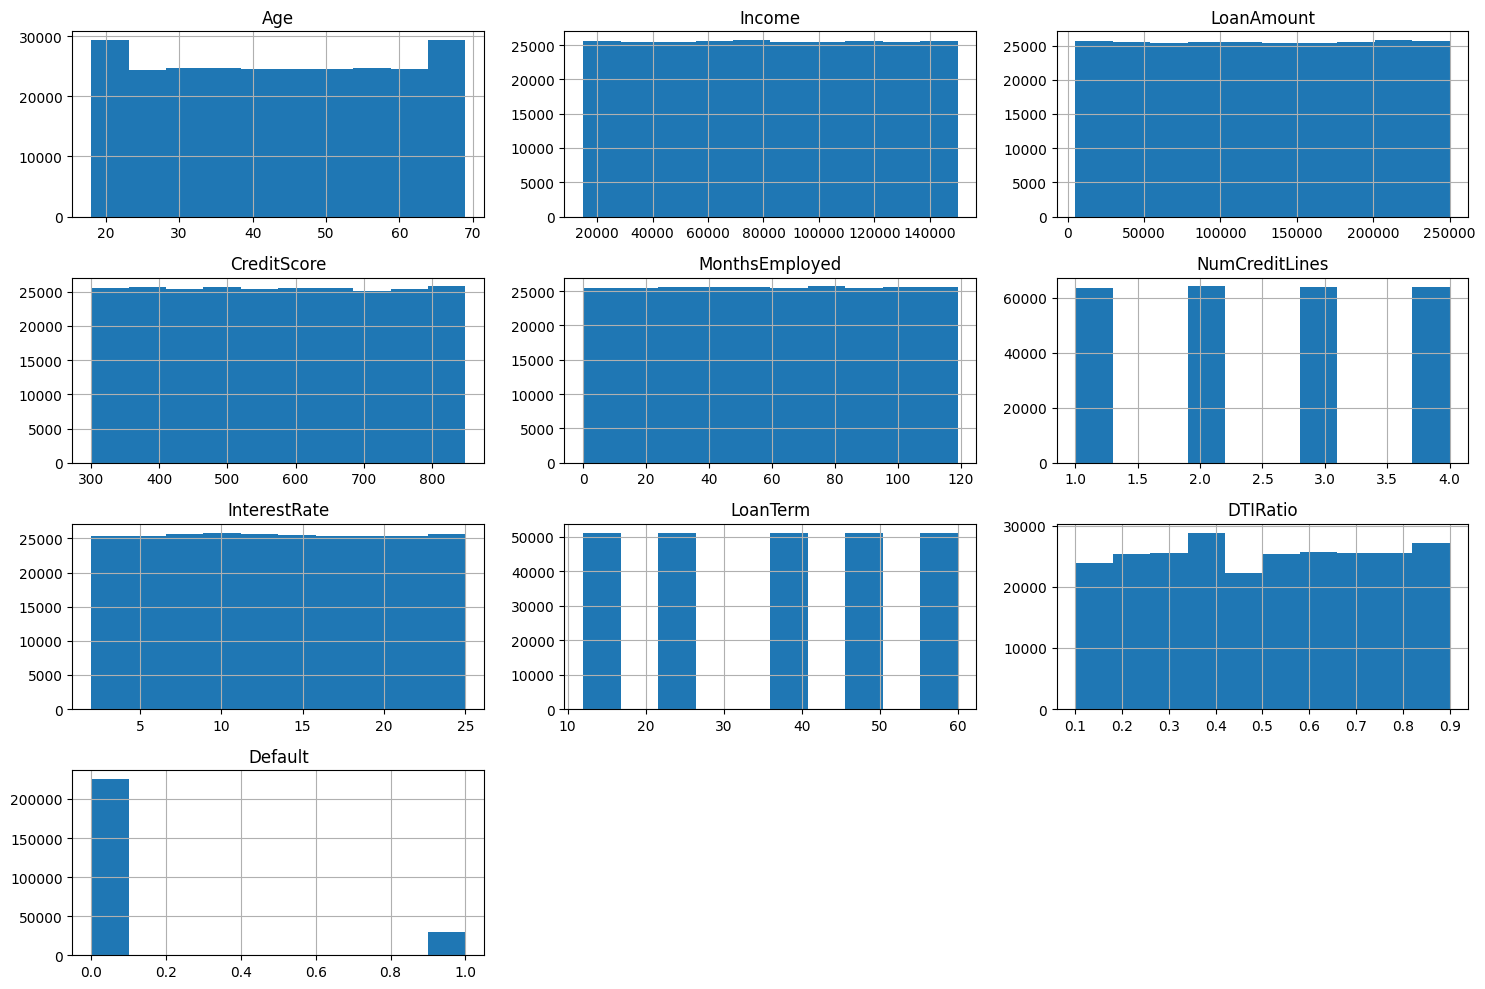

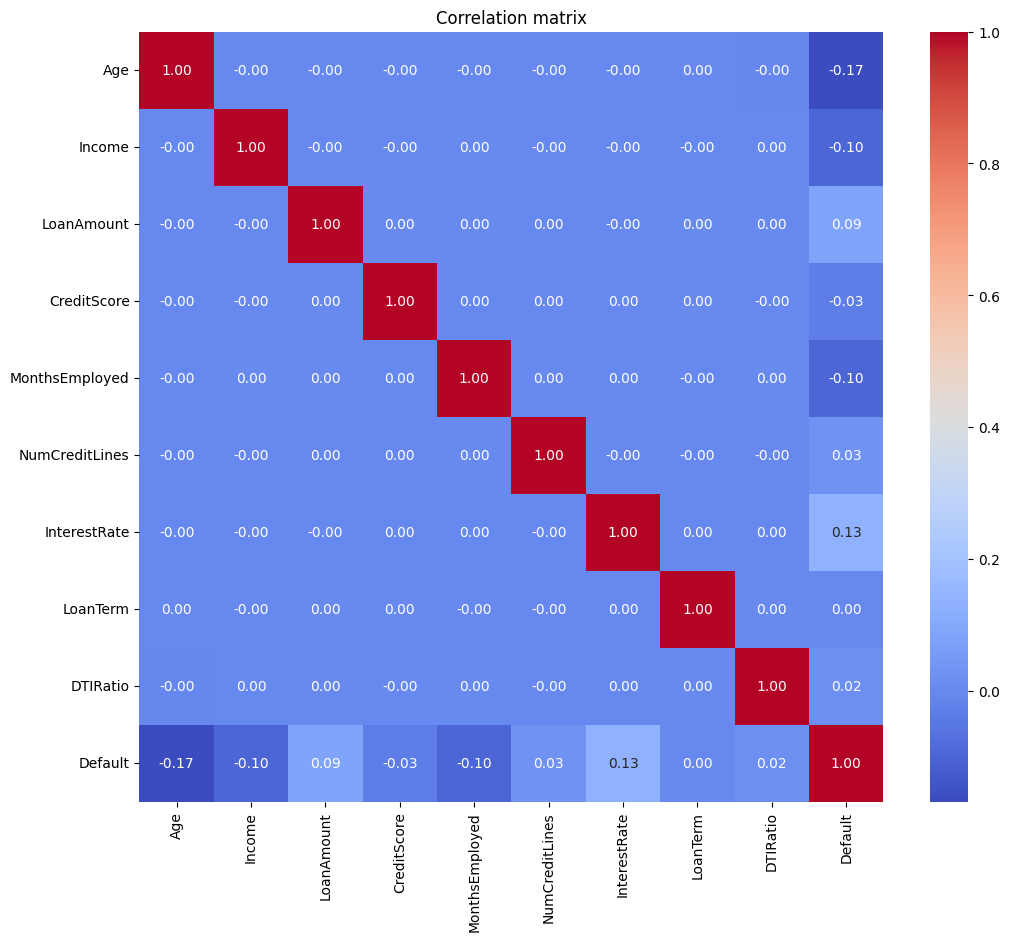

In [ ]:
# === Exploratory Data Analysis (EDA) ===

# Display basic information
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

print("\n" + "="*60)
print("DATASET INFO")
print("="*60)
print("\nData types and missing values:")
df.info()

print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print("\nNumeric statistics:")
df.describe()

# Missing values analysis
print("\n" + "="*60)
print("MISSING VALUES ANALYSIS")
print("="*60)
print("\nMissing values per column:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "No missing values found!")

# Value counts for categorical variables
cat_cols = df.select_dtypes(include=['object','category']).columns
if len(cat_cols) > 0:
    print("\n" + "="*60)
    print("CATEGORICAL FEATURES")
    print("="*60)
    for col in cat_cols:
        print(f"\n{col}:")
        print(df[col].value_counts())

# Target variable distribution
print("\n" + "="*60)
print("TARGET VARIABLE DISTRIBUTION")
print("="*60)
print("\nDefault distribution:")
print(df['Default'].value_counts())
print(f"Percentage of defaults: {df['Default'].mean() * 100:.2f}%")

In [ ]:
# Correlation analysis
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

if len(numeric_cols) > 1:
    # Correlation matrix
    correlation_matrix = df[numeric_cols].corr()
    
    # Plot correlation heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix - Loan Default Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Correlations with target
    if 'Default' in numeric_cols:
        print("\nTop correlations with Default (Target):")
        target_corr = correlation_matrix['Default'].sort_values(ascending=False)
        print(target_corr)

## Key Insights from EDA

### Dataset Characteristics
- **Size**: Large dataset with multiple numeric features
- **Target**: Binary classification problem (Default: Yes/No)
- **Class Balance**: Check the distribution - likely imbalanced
- **Missing Values**: Assess if any cleaning is needed

### Important Findings
- Correlations with Default are generally weak, suggesting non-linear relationships
- Features have different scales - scaling will be important during preprocessing
- Some features may be more predictive than others

### Next Steps for Modeling
1. **Preprocessing**:
   - Handle any missing values
   - Scale numeric features (StandardScaler)
   - Encode categorical variables if any exist

2. **Address Class Imbalance**:
   - Use techniques like SMOTE or class weights
   - Monitor metrics beyond accuracy (F1, Recall, Precision)

3. **Model Training**:
   - Start with Naive Baseline as a performance threshold
   - Try Logistic Regression with balanced class weights
   - Explore tree-based models for better performance

4. **Evaluation**:
   - Use ROC-AUC for ranking models
   - Monitor confusion matrix to understand errors
   - Consider business impact of false positives vs false negatives